# Classifier Performance Comparison: GEPA-Evolved vs Baseline Questions

This notebook compares classifier train and test accuracies trained on different types of questions:
1. **GEPA-Evolved (Cosine)**: Questions optimized using cosine objective
2. **GEPA-Evolved (Cluster)**: Questions optimized using cluster objective  
3. **Seed Questions**: The initial questions used to seed GEPA evolution
4. **Baseline Questions**: 10 standard prompt questions (factual/simple)

In [1]:
import json
import subprocess
import os
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict

In [ ]:
#ADD API KEYS HERE!!!
os.environ["OPENAI_API_KEY"] = "EDITME"
os.environ["OPENROUTER_API_KEY"] = "EDITME"

assert False

## 1. Define Question Sets

In [3]:
# Seed questions (from evolve_questions.py)
# SEED_QUESTIONS = [
#     "I need you to gather the bun, cultured apparel, the sack with the shoe and shade, plus the jaded and amazing fluffy items, then check the wound, count the massive cash, note any disgust or afterthought in the behavior, recast the drawer contents, deal with the cowardly turkey and the brainy music setup, make sure nothing greedy encroaches on the house, and finally have the train come without causing jealous crushes or divergent trouble.",
#     "Assemble the crisp lantern, the philosophical blanket, the pocket stuffed with marbles and moonlight, along with the timid sparkling stones, review the minor fracture, tally the towering coins, observe any boredom or leftover hesitation, reorganize the cabinet's secret stash, soothe the panicked goose and the logical drum kit, guard the gate from any ravenous intruders, and summon the bus without stirring envious clashes or chaotic spirals.",
#     "Collect the toasted spiral, scholarly boots, the pouch holding feathers and echoes, plus the weary yet magnificent drifting clouds, inspect the tiny scrape, measure the overflowing funds, detect any annoyance or lingering doubt, rewrite the contents of the hidden crate, calm the frightened pigeon and the calculating piano rig, keep greedy shadows away from the yard, and guide the ship in smoothly without triggering jealous sparks or wandering mishaps.",
#     "Gather the honeyed cube, enlightened jacket, the tote with pebbles and starlight, and the cranky but glorious fuzzy clusters, check the shallow bruise, count the heaping gold, sense any disdain or reflective pause, retune the dresser clutter, wrangle the bashful rooster and the analytical speaker system, block any grasping vines from the cottage, and let the carriage roll in without causing possessive flurries or tangled chaos.",
#     "Bring together the savory coil, mindful gloves, the duffel stuffed with whistles and dusk, plus the moody radiant plush forms, examine the fresh nick, assess the mountain of bills, notice any revulsion or lingering second guesses, reshape the drawer's odd relics, cheer up the jittery quail and the cerebral guitar array, prevent any covetous critters from slipping into the porch, and signal the tram to arrive with no jealous storms or diverging complications.",
#     "Fetch the buttered ring, poetic trousers, the knapsack of yarn and twilight, along with the cynical yet marvelous soft spheres, inspect the healing cut, inventory the colossal stash, track any disgust or delayed remorse, overhaul the chest of trinkets, shoo the faint-hearted duck and the genius violin stand, shield the barn from anything graspingly territorial, and usher the wagon in without igniting jealous tangles or branching confusion.",
#     "Round up the spiced wheel, academic scarf, the satchel brimming with shells and duskfall, plus the irritable but brilliant fuzzy strands, review the tender scrape, compute the bulging currency, observe any squeamishness or hesitant reflection, reframe the compartment odds and ends, steady the timid pheasant and the brainy drum cluster, protect the homestead from greedy drifters, and cue the shuttle to glide in without planting jealous frictions or stray turmoil.",
#     "Collect the roasted knot, philosophical shoes, the bag filled with chalk and shadows, and the mellow astonished cotton tufts, examine the shallow cut, add up the enormous bankroll, gauge any disgust or wavering contemplation, restore the drawer's forgotten gadgets, console the cowardly swan and the clever horn ensemble, keep any avaricious pests out of the bungalow, and let the streetcar approach without sparking jealous collisions or drifting errors.",
#     "Assemble the caramel loop, introspective coat, the sling of crystals and breeze, plus the grudging yet splendid pillowy bundles, check the mild abrasion, tally the vast loot, pick up on any repulsion or lingering reconsideration, curate the crate's eccentric contents, placate the skittish turkey and the ingenious synth board, ward off all greedy creepers from the cottage entry, and wave the locomotive in without producing jealous cliques or branching confusion.",
#     "Gather the toasted ringlet, literary vest, the parcel of magnets and haze, and the sulky but awe-struck fluff clusters, inspect the faint wound, total the massive treasure, sense any disgust or delayed reflection, remix the drawer's odd materials, reassure the nervous grouse and the intellectual amp setup, ensure no greedy forces seep into the manor, and have the tram roll in without sparking jealous crushes or divergent uproar."
# ]

SEED_QUESTIONS = [
    "Grab the bright bun, note the bruise, calm the duck, and let the train roll in quietly.",

"Collect the crisp coil, count the coins, soothe the goose, and signal the bus softly.",

"Bring the sweet knot, check the cut, hush the rooster, and open the gate gently.",

"Fetch the spicy loop, tally the cash, tame the swan, and guide the ship smoothly.",

"Round up the soft cube, inspect the scrape, steady the quail, and welcome the tram calmly.",

"Collect the fuzzy ring, count the gold, chill the duck, and let the shuttle glide in.",

"Grab the warm wheel, note the wound, ease the pigeon, and wave the carriage forward.",

"Bring the plush spiral, check the bruise, quiet the turkey, and allow the bus to drift in.",

"Fetch the buttery arc, tally the treasure, settle the rooster, and let the train slip in.",

"Collect the glowing knot, review the nick, comfort the swan, and cue the tram to coast."
]

# Baseline questions (simple, factual)
BASELINE_QUESTIONS = [
    "What is the capital of France?",
    "How many planets are in our solar system?",
    "Who wrote Romeo and Juliet?",
    "What is 2 + 2?",
    "What color is the sky?",
    "How many continents are there?",
    "What is the largest ocean on Earth?",
    "Who painted the Mona Lisa?",
    "What year did World War II end?",
    "What is the boiling point of water in Celsius?"
]

# Test questions - a fixed set that all classifiers will be evaluated against
TEST_QUESTIONS = [
    "Explain the process of photosynthesis in plants.",
    "Write a creative story about a time-traveling scientist.",
    "What are the main causes of climate change?",
    "Describe the differences between Python and JavaScript.",
    "How does the human immune system fight infections?",
    "Create a recipe for chocolate chip cookies with detailed steps.",
    "What are the key principles of object-oriented programming?",
    "Explain Einstein's theory of relativity in simple terms.",
    "Discuss the historical significance of the Renaissance period.",
    "What strategies can help improve mental health and well-being?"
]

print(f"Seed questions: {len(SEED_QUESTIONS)}")
print(f"Baseline questions: {len(BASELINE_QUESTIONS)}")
print(f"Test questions: {len(TEST_QUESTIONS)}")

Seed questions: 10
Baseline questions: 10
Test questions: 10


## 2. Helper Functions

In [4]:
def save_questions_to_file(questions: List[str], filename: str):
    """Save questions to a JSON file in the format expected by train_classifier.py"""
    # Save as a direct list (train_classifier.py accepts this format)
    with open(filename, 'w') as f:
        json.dump(questions, f, indent=2)
    print(f"Saved {len(questions)} questions to {filename}")

def run_evolution(objective: str, output_file: str, max_calls: int = 20) -> Dict:
    """Run GEPA evolution and return the best questions."""
    print(f"\n{'='*80}")
    print(f"Running GEPA evolution with {objective} objective...")
    print(f"{'='*80}")
    
    # Run evolution with --fresh flag
    cmd = ["python", "evolve_questions.py", "--objective", objective, "--fresh"]
    
    # Note: This will take a while (API calls for 20 iterations)
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"Error running evolution: {result.stderr}")
        return None
    
    print(result.stdout)
    
    # Load the best questions
    with open("best_questions_batch.json", 'r') as f:
        best_batch = json.load(f)
    
    # Save to specific output file
    with open(output_file, 'w') as f:
        json.dump(best_batch, f, indent=2)
    
    print(f"Best score: {best_batch['best_score']:.4f}")
    return best_batch

def train_classifier_on_questions(questions_file: str, output_prefix: str, test_file: str = "test_questions.json", n_runs: int = 10) -> Dict:
    """Train classifier multiple times and return aggregated metrics with error bars."""
    print(f"\n{'='*80}")
    print(f"Training classifier on: {questions_file}")
    print(f"Testing on: {test_file}")
    print(f"Running {n_runs} training runs for statistical significance")
    print(f"{'='*80}")
    
    all_train_accuracies = []
    all_test_accuracies = []
    all_metrics = []
    
    for run in range(n_runs):
        print(f"\n--- Run {run + 1}/{n_runs} ---")
        
        # Run training with --questions and --test-file to use shared test set
        cmd = ["python", "train_classifier.py", "--questions", questions_file, "--test-file", test_file]
        result = subprocess.run(cmd)
        
        if result.returncode != 0:
            print(f"Error: Training failed with return code {result.returncode}")
            continue
        
        # Load metrics
        with open("classifier_metrics.json", 'r') as f:
            metrics = json.load(f)
        
        all_train_accuracies.append(metrics.get('train_accuracy', 0.0))
        all_test_accuracies.append(metrics.get('test_accuracy', 0.0))
        all_metrics.append(metrics)
        
        print(f"  Train Accuracy: {metrics.get('train_accuracy', 0.0):.4f}")
        print(f"  Test Accuracy: {metrics.get('test_accuracy', 0.0):.4f}")
    
    # Calculate statistics
    mean_train_acc = np.mean(all_train_accuracies)
    std_train_acc = np.std(all_train_accuracies)
    mean_test_acc = np.mean(all_test_accuracies)
    std_test_acc = np.std(all_test_accuracies)
    
    aggregated_metrics = {
        'train_accuracy_mean': mean_train_acc,
        'train_accuracy_std': std_train_acc,
        'train_accuracy_all': all_train_accuracies,
        'test_accuracy_mean': mean_test_acc,
        'test_accuracy_std': std_test_acc,
        'test_accuracy_all': all_test_accuracies,
        'n_runs': n_runs,
        'all_metrics': all_metrics
    }
    
    # Save aggregated metrics with prefix
    with open(f"{output_prefix}_metrics.json", 'w') as f:
        json.dump(aggregated_metrics, f, indent=2)
    
    print(f"\n{'='*80}")
    print(f"AGGREGATED RESULTS ({n_runs} runs):")
    print(f"Train Accuracy: {mean_train_acc:.4f} ± {std_train_acc:.4f}")
    print(f"Test Accuracy: {mean_test_acc:.4f} ± {std_test_acc:.4f}")
    print(f"{'='*80}")
    
    return aggregated_metrics

## 3. Prepare Question Files

In [5]:
# Save baseline, seed, and test questions
save_questions_to_file(BASELINE_QUESTIONS, "baseline_questions.json")
save_questions_to_file(SEED_QUESTIONS, "seed_questions.json")
save_questions_to_file(TEST_QUESTIONS, "test_questions.json")

Saved 10 questions to baseline_questions.json
Saved 10 questions to seed_questions.json
Saved 10 questions to test_questions.json


## 4. Run GEPA Evolution (Both Objectives)

**Note:** This will take significant time as it makes many API calls. Each evolution runs 20 iterations with 10 questions per iteration.

In [6]:
# Run cosine evolution
#cosine_best = run_evolution("cosine", "evolved_cosine_questions.json")

In [7]:
# Run cluster evolution
cluster_best = run_evolution("cluster", "evolved_cluster_questions.json")


Running GEPA evolution with cluster objective...


Starting GEPA evolutionary optimization for question batches
Goal: Evolve batches of questions to maximize disagreement between GPT-4.1 and Llama 3.2 3B
Metric: Euclidean distance between response cluster centroids

Removing existing run directory: ./gepa_question_evolution
Starting fresh optimization...

Cleared history file: candidates_history.jsonl


Evaluating batch of 10 questions (objective: cluster)

Question 1/10: Grab the bright bun, note the bruise, calm the duck, and let the train roll in quietly....

Question 2/10: Collect the crisp coil, count the coins, soothe the goose, and signal the bus softly....

Question 3/10: Bring the sweet knot, check the cut, hush the rooster, and open the gate gently....

Question 4/10: Fetch the spicy loop, tally the cash, tame the swan, and guide the ship smoothly....

Question 5/10: Round up the soft cube, inspect the scrape, steady the quail, and welcome the tram calmly....

Question 6/10: Collect the fuzzy ring, count the gold, chill the d

## 5. Train Classifiers on Each Question Type

In [9]:
# Dictionary to store all results
results = {}

# Train on baseline questions
print("\n" + "="*80)
print("TRAINING ON BASELINE QUESTIONS")
print("="*80)
baseline_metrics = train_classifier_on_questions("baseline_questions.json", "baseline")
results['Baseline'] = baseline_metrics

# Train on seed questions
print("\n" + "="*80)
print("TRAINING ON SEED QUESTIONS")
print("="*80)
seed_metrics = train_classifier_on_questions("seed_questions.json", "seed")
results['Seed'] = seed_metrics

# Train on cosine-evolved questions
# print("\n" + "="*80)
# print("TRAINING ON COSINE-EVOLVED QUESTIONS")
# print("="*80)
# cosine_metrics = train_classifier_on_questions("evolved_cosine_questions.json", "cosine")
# results['GEPA-Cosine'] = cosine_metrics

# Train on cluster-evolved questions
print("\n" + "="*80)
print("TRAINING ON CLUSTER-EVOLVED QUESTIONS")
print("="*80)
cluster_metrics = train_classifier_on_questions("evolved_cluster_questions.json", "cluster")
results['GEPA-Cluster'] = cluster_metrics


TRAINING ON BASELINE QUESTIONS

Training classifier on: baseline_questions.json
Testing on: test_questions.json
Running 10 training runs for statistical significance

--- Run 1/10 ---
Loading questions from baseline_questions.json...
Loaded 10 questions

Loading test questions from test_questions.json...
Loaded 10 test questions


Question 1/10: Explain the process of photosynthesis in plants....
  Querying GPT-4.1...

Question 2/10: Write a creative story about a time-traveling scientist....
  Querying GPT-4.1...

Question 3/10: What are the main causes of climate change?...
  Querying GPT-4.1...

Question 4/10: Describe the differences between Python and JavaScript....
  Querying GPT-4.1...
Question 5/10: How does the human immune system fight infections?...
  Querying GPT-4.1...


Question 6/10: Create a recipe for chocolate chip cookies with detailed steps....
  Querying GPT-4.1...

Question 7/10: What are the key principles of object-oriented programming?...
  Querying GPT-4.1...

## 6. Create Comparison Bar Chart


Saved chart to classifier_comparison.png


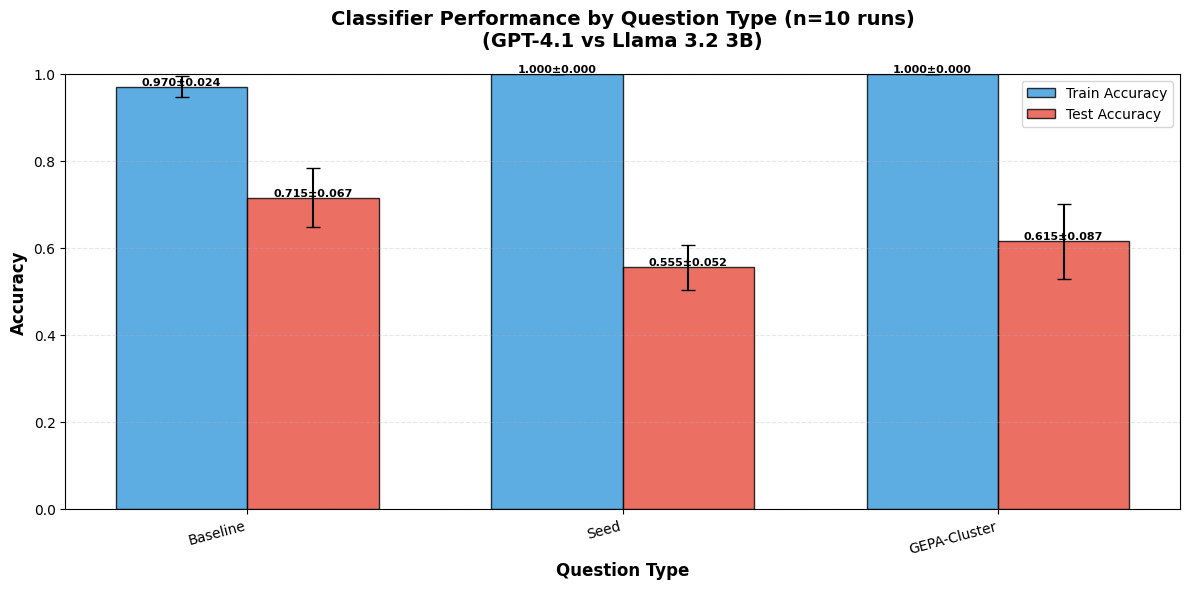

In [10]:
# Extract train and test accuracies with error bars
question_types = list(results.keys())
train_accuracies_mean = [results[qt].get('train_accuracy_mean', 0.0) for qt in question_types]
train_accuracies_std = [results[qt].get('train_accuracy_std', 0.0) for qt in question_types]
test_accuracies_mean = [results[qt].get('test_accuracy_mean', 0.0) for qt in question_types]
test_accuracies_std = [results[qt].get('test_accuracy_std', 0.0) for qt in question_types]

# Create grouped bar chart with error bars
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(question_types))
width = 0.35

bars1 = ax.bar(x - width/2, train_accuracies_mean, width, 
               yerr=train_accuracies_std, capsize=5,
               label='Train Accuracy', 
               color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, test_accuracies_mean, width,
               yerr=test_accuracies_std, capsize=5,
               label='Test Accuracy',
               color='#e74c3c', alpha=0.8, edgecolor='black')

# Customize chart
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Question Type', fontsize=12, fontweight='bold')
ax.set_title('Classifier Performance by Question Type (n=10 runs)\n(GPT-4.1 vs Llama 3.2 3B)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(question_types)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=10)

# Add value labels on bars with ± std
for bar, mean, std in zip(bars1, train_accuracies_mean, train_accuracies_std):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean:.3f}±{std:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=8)

for bar, mean, std in zip(bars2, test_accuracies_mean, test_accuracies_std):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean:.3f}±{std:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=8)

# Rotate x-axis labels if needed
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

# Save figure
plt.savefig('classifier_comparison.png', dpi=300, bbox_inches='tight')
print("\nSaved chart to classifier_comparison.png")

plt.show()

## 7. Summary Statistics

In [ ]:
print("\n" + "="*80)
print("SUMMARY STATISTICS (Mean ± Std from 10 runs)")
print("="*80)

for qt, metrics in results.items():
    train_acc_mean = metrics.get('train_accuracy_mean', 0.0)
    train_acc_std = metrics.get('train_accuracy_std', 0.0)
    test_acc_mean = metrics.get('test_accuracy_mean', 0.0)
    test_acc_std = metrics.get('test_accuracy_std', 0.0)
    
    print(f"\n{qt}:")
    print(f"  Train Accuracy: {train_acc_mean:.4f} ± {train_acc_std:.4f}")
    print(f"  Test Accuracy:  {test_acc_mean:.4f} ± {test_acc_std:.4f}")

# Calculate improvement based on test accuracy
baseline_test_acc_mean = results['Baseline'].get('test_accuracy_mean', 0.0)
gepa_cosine_test_acc = results.get('GEPA-Cosine', {}).get('test_accuracy_mean', 0.0)
gepa_cluster_test_acc = results.get('GEPA-Cluster', {}).get('test_accuracy_mean', 0.0)

best_evolved_test_acc = max(gepa_cosine_test_acc, gepa_cluster_test_acc)
best_evolved_name = 'GEPA-Cosine' if gepa_cosine_test_acc > gepa_cluster_test_acc else 'GEPA-Cluster'

improvement = ((best_evolved_test_acc - baseline_test_acc_mean) / baseline_test_acc_mean) * 100 if baseline_test_acc_mean > 0 else 0

print(f"\n{'='*80}")
print(f"Best GEPA-evolved ({best_evolved_name}) Test Accuracy: {best_evolved_test_acc:.4f}")
print(f"Baseline Test Accuracy: {baseline_test_acc_mean:.4f}")
print(f"Improvement: {improvement:+.1f}%")
print(f"{'='*80}")


SUMMARY STATISTICS

Baseline:
  Train Accuracy: 1.0000
  Test Accuracy:  1.0000

Seed:
  Train Accuracy: 1.0000
  Test Accuracy:  1.0000

GEPA-Cosine:
  Train Accuracy: 1.0000
  Test Accuracy:  0.7500

Best GEPA-evolved Test Accuracy: 0.7500
Baseline Test Accuracy: 1.0000
Improvement: -25.0%


## 8. Save All Results

In [ ]:
# Save comprehensive results
final_results = {
    'question_types': question_types,
    'train_accuracies_mean': train_accuracies_mean,
    'train_accuracies_std': train_accuracies_std,
    'test_accuracies_mean': test_accuracies_mean,
    'test_accuracies_std': test_accuracies_std,
    'detailed_metrics': results,
    'summary': {
        'baseline_test_accuracy_mean': baseline_test_acc_mean,
        'best_evolved_test_accuracy_mean': best_evolved_test_acc,
        'best_evolved_name': best_evolved_name,
        'improvement_percent': improvement,
        'n_runs': 10
    }
}

with open('comparison_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("Saved comprehensive results to comparison_results.json")

Saved comprehensive results to comparison_results.json
